# Un millón de animales muertos: encontraron al culpable en el agua

En 2025, la costa de Australia del Sur amaneció con la playa cubierta de cadáveres: peces, tiburones, pulpos, erizos. Cerca de **un millón de animales** de **más de 600 especies** murieron a lo largo de **20.000 km²** durante más de un año. Un equipo tomó 115 muestras de agua, contó el ADN de siete algas del género *Karenia*, y una sola dominó el 88,6% de todas las células: una especie nueva, *Karenia cristata*.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *A catastrophic marine mortality event caused by a complex algal bloom including the brevetoxin producer Karenia cristata* — Nature Ecology & Evolution (2026).
**DOI:** [10.1038/s41559-026-03115-0](https://doi.org/10.1038/s41559-026-03115-0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-08-karenia-cristata-mortandad-marina/notebook.ipynb)

## Qué estamos mirando

Una floración de algas nocivas (HAB, por sus siglas en inglés) no es rara. Lo raro fue el tamaño y quién la causó. El equipo hizo tres cosas que podemos revisar con sus datos:

1. **Contar** cuánta de cada especie de *Karenia* había en el agua (qPCR, 115 muestras entre marzo y septiembre de 2025).
2. **Medir** qué tan tóxica es la culpable sobre células de branquia de pez, en el laboratorio.
3. **Confirmar** que el cultivo aislado de *K. cristata* mata invertebrados igual que el agua sacada del mar.

Empecemos por lo primero: ¿quién estaba en el agua?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESPECIE_FOCO = 'K. cristata'      # la sospechosa
GILL_EC50 = 27.2                  # cell/mL — concentración que mata la mitad de las células de branquia
FUENTE = 'Fuente: Nature Ecology & Evolution (2026) | Datos: Zenodo 10.5281/zenodo.20227729'

COLOR_DATOS = '#2563EB'           # azul CaM
COLOR_ALERTA = '#DC2626'          # rojo — la culpable / el umbral letal
COLOR_SECUND = '#059669'          # emerald — datos secundarios
COLOR_REFERENCIA = '#D97706'      # amber — referencia
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga de los tres datasets
abund = pd.read_csv('datos/abundancia_karenia_qpcr.csv')
gill = pd.read_csv('datos/viabilidad_branquias_rtgill.csv')
inv = pd.read_csv('datos/mortalidad_invertebrados.csv')

karenia_cols = [c for c in abund.columns if c.startswith('K.')]
print(f'qPCR: {abund.shape[0]} muestras, {abund["site"].nunique()} sitios, {abund["date"].nunique()} fechas')
print(f'Branquias (RTgill-W1): {gill.shape[0]} mediciones, {gill["conc_cell_mL"].nunique()} concentraciones')
print(f'Invertebrados: {inv.shape[0]} filas — {list(inv["test"].unique())} x fuentes {list(inv["source"].unique())}')

qPCR: 115 muestras, 36 sitios, 22 fechas
Branquias (RTgill-W1): 40 mediciones, 8 concentraciones
Invertebrados: 176 filas — ['Rotifers', 'Artemia'] x fuentes ['WL', 'KC']


Sumamos todas las células de cada especie, a través de las 115 muestras. Aquí está.

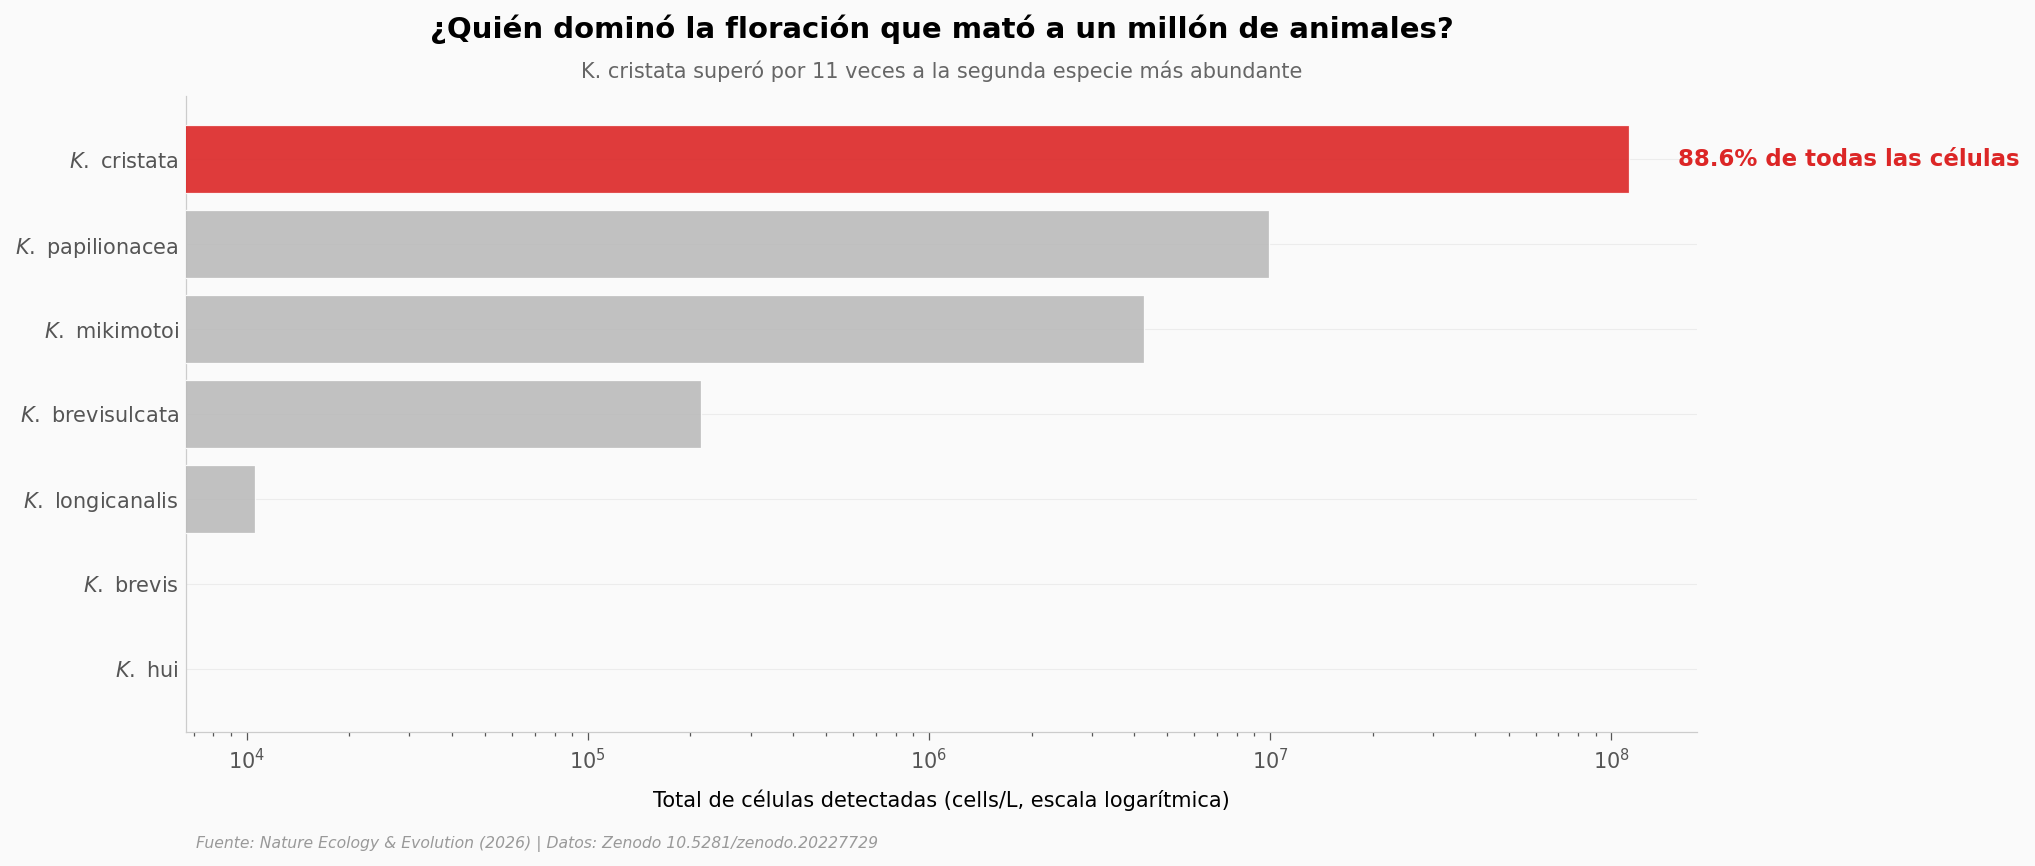

K. cristata: 88.6% del total | 11.3x sobre la 2a especie
Especie más abundante muestra por muestra: K. cristata en 96 de 115 muestras


In [2]:
# Total de células por especie (suma cross-muestras) + dominancia por muestra
totales = abund[karenia_cols].sum().sort_values()
total_karenia = totales.sum()
pct_cristata = 100 * totales[ESPECIE_FOCO] / total_karenia
ratio = totales[ESPECIE_FOCO] / totales.drop(ESPECIE_FOCO).max()

fig, ax = plt.subplots(figsize=(13, 5.5))
colores = [COLOR_ALERTA if s == ESPECIE_FOCO else COLOR_GRIS for s in totales.index]
barras = ax.barh(range(len(totales)), totales.values, color=colores, alpha=0.9,
                 edgecolor='white', linewidth=0.6, zorder=3)
ax.set_yticks(range(len(totales)))
ax.set_yticklabels([s.replace('K.', '$K.$') for s in totales.index], fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('Total de células detectadas (cells/L, escala logarítmica)', fontsize=10)

# Etiqueta de la culpable
idx_foco = list(totales.index).index(ESPECIE_FOCO)
ax.text(totales[ESPECIE_FOCO] * 1.4, idx_foco,
        f'{pct_cristata:.1f}% de todas las células',
        va='center', fontsize=11, fontweight='bold', color=COLOR_ALERTA)

ax.set_title('¿Quién dominó la floración que mató a un millón de animales?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{ESPECIE_FOCO} superó por {ratio:.0f} veces a la segunda especie más abundante',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dominancia_qpcr.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{ESPECIE_FOCO}: {pct_cristata:.1f}% del total | {ratio:.1f}x sobre la 2a especie')
dominante = abund[karenia_cols].idxmax(axis=1)
print(f'Especie más abundante muestra por muestra: {ESPECIE_FOCO} en '
      f'{(dominante == ESPECIE_FOCO).sum()} de {len(abund)} muestras')

La barra roja no deja lugar a dudas: de cada 100 células de *Karenia* en el agua, casi 89 eran de esta especie nueva. Y no es que estuviera repartida por igual — en 96 de las 115 muestras fue la más abundante. Cuando una sola especie aplasta así a las otras seis, deja de ser una sospechosa entre varias.

Pero ser abundante no es lo mismo que ser letal. Que *K. cristata* estuviera en todas partes no prueba que ella matara a los animales. Para eso hay que medir su veneno.

## Del conteo al veneno

El equipo expuso células de branquia de trucha (línea RTgill-W1) al líquido donde creció *K. cristata*, a ocho concentraciones distintas, y midió cuántas seguían vivas después de dos horas.

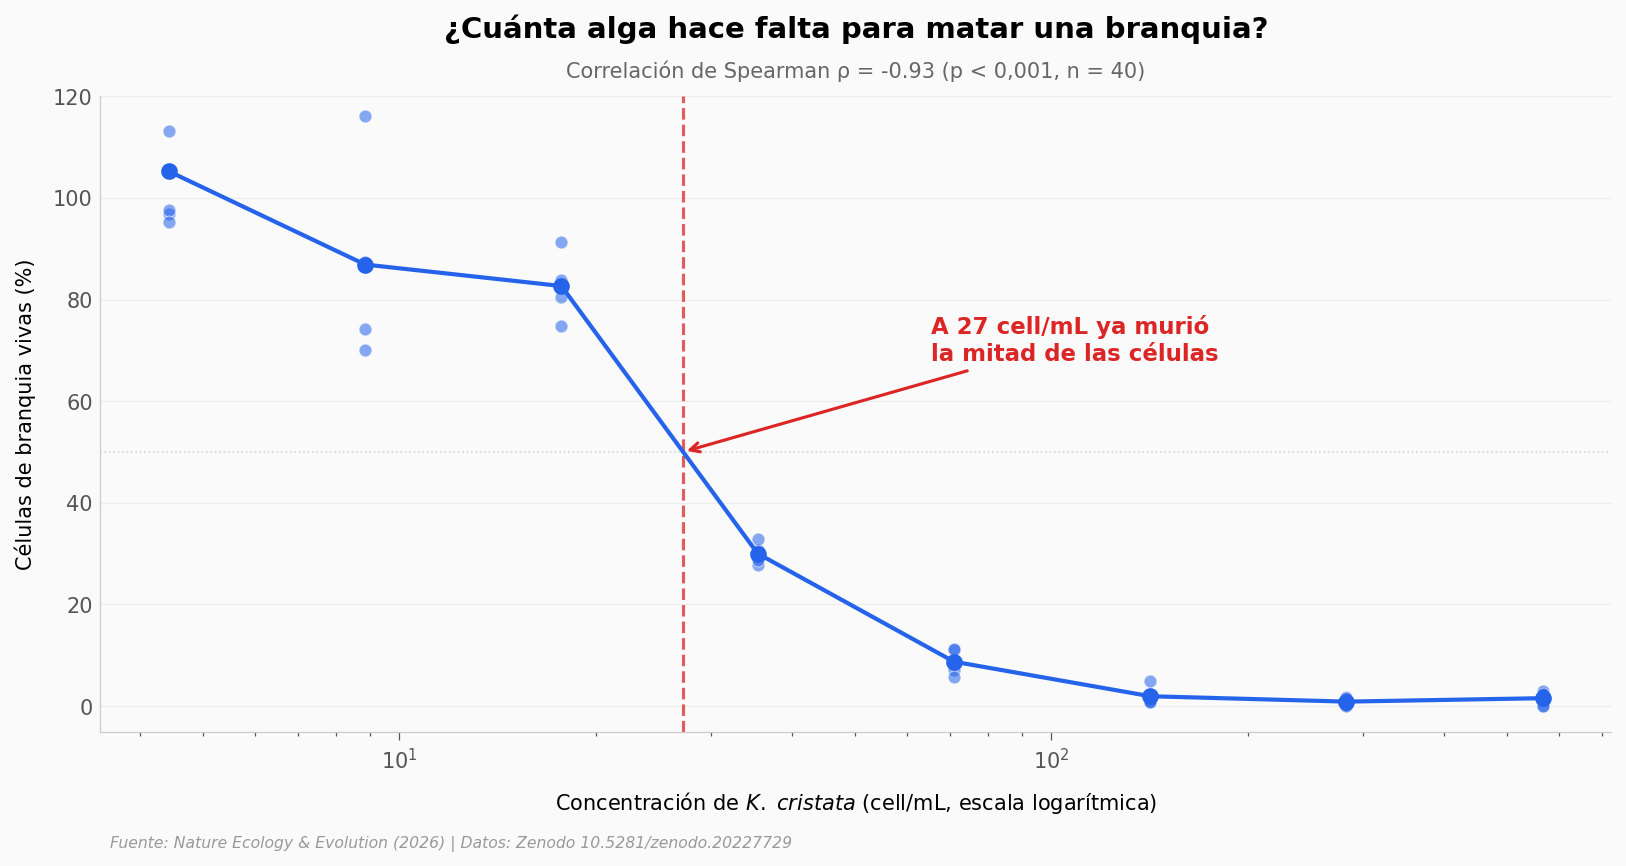

Viabilidad a 4.4 cell/mL: 105%
Viabilidad a 567 cell/mL: 1.6%
Spearman ρ = -0.933, p = 1.8e-18


In [3]:
# Dosis-respuesta en branquias: viabilidad vs concentración
resumen = gill.groupby('conc_cell_mL')['viability_pct'].agg(['mean', 'std', 'count']).reset_index()
rho, p = stats.spearmanr(gill['conc_cell_mL'], gill['viability_pct'])

fig, ax = plt.subplots(figsize=(13, 5.5))
# puntos individuales (jitter en x log)
ax.scatter(gill['conc_cell_mL'], gill['viability_pct'] * 100, color=COLOR_DATOS,
           s=38, alpha=0.55, edgecolors='white', linewidths=0.5, zorder=4)
# media por concentración
ax.plot(resumen['conc_cell_mL'], resumen['mean'] * 100, color=COLOR_DATOS,
        linewidth=2, marker='o', markersize=7, zorder=5)
# umbral letal EC50
ax.axvline(x=GILL_EC50, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.75)
ax.annotate(f'A {GILL_EC50:.0f} cell/mL ya murió\nla mitad de las células',
            xy=(GILL_EC50, 50), xytext=(GILL_EC50 * 2.4, 68),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.axhline(y=50, color=COLOR_GRIS, linewidth=0.8, linestyle=':', alpha=0.6)

ax.set_xscale('log')
ax.set_xlabel('Concentración de $K.$ $cristata$ (cell/mL, escala logarítmica)', fontsize=10)
ax.set_ylabel('Células de branquia vivas (%)', fontsize=10)
ax.set_ylim(-5, 120)
ax.set_title('¿Cuánta alga hace falta para matar una branquia?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Correlación de Spearman ρ = {rho:.2f} (p < 0,001, n = {len(gill)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/branquias_dosis.png', dpi=200, bbox_inches='tight')
plt.show()

lo = resumen.iloc[0]; hi = resumen.iloc[-1]
print(f'Viabilidad a {lo.conc_cell_mL:.1f} cell/mL: {lo["mean"]*100:.0f}%')
print(f'Viabilidad a {hi.conc_cell_mL:.0f} cell/mL: {hi["mean"]*100:.1f}%')
print(f'Spearman ρ = {rho:.3f}, p = {p:.1e}')

## ¿Es el alga, o algo más del mar?

Queda una duda honesta: el agua de mar trae mil cosas. Quizá lo que mató a las branquias no era *K. cristata* sino otro pasajero de la muestra. El equipo cerró esa puerta con un control: comparó el material sacado del campo (West Lakes, **WL**) contra un cultivo aislado y limpio de *K. cristata* (**KC**), sobre dos animales de prueba — rotíferos y *Artemia* (el camarón de acuario). Si el cultivo puro mata igual que el agua del mar, la culpable es el alga.

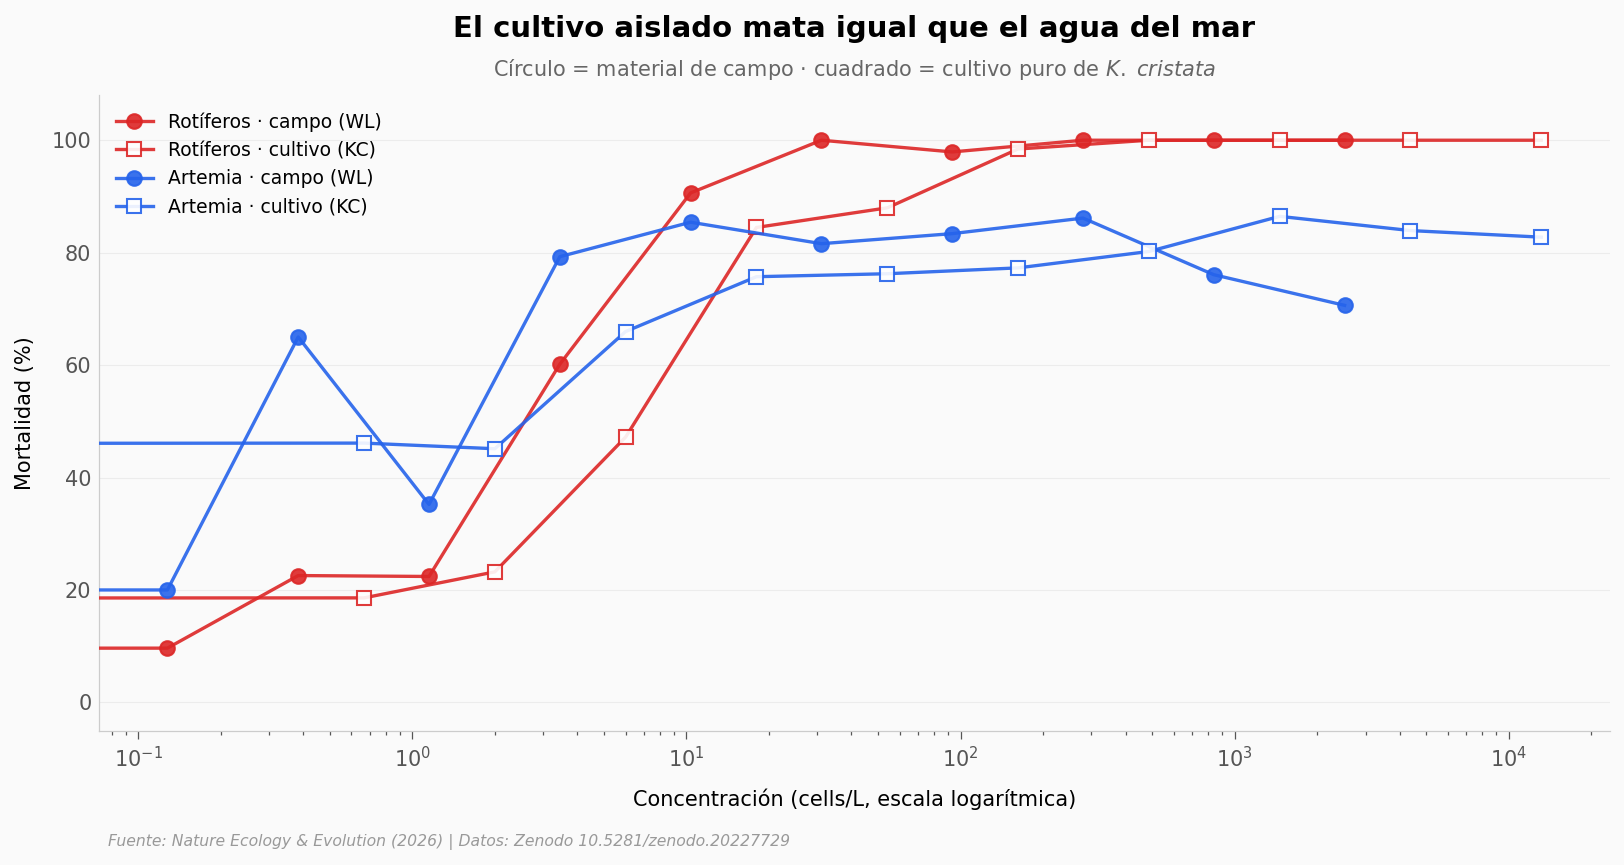

Rotifers  WL: Spearman ρ = 0.91 (p = 5.0e-18)
Rotifers  KC: Spearman ρ = 0.91 (p = 1.2e-17)
Artemia   WL: Spearman ρ = 0.56 (p = 8.9e-05)
Artemia   KC: Spearman ρ = 0.68 (p = 3.8e-07)
Rotifers: 4% (control) → 100% (dosis máxima)
Artemia: 18% (control) → 83% (dosis máxima)


In [4]:
# Mortalidad de invertebrados: campo (WL) vs cultivo aislado (KC)
estilos = {
    ('Rotifers', 'WL'): dict(color=COLOR_ALERTA, marker='o', label='Rotíferos · campo (WL)'),
    ('Rotifers', 'KC'): dict(color=COLOR_ALERTA, marker='s', label='Rotíferos · cultivo (KC)'),
    ('Artemia', 'WL'):  dict(color=COLOR_DATOS,  marker='o', label='Artemia · campo (WL)'),
    ('Artemia', 'KC'):  dict(color=COLOR_DATOS,  marker='s', label='Artemia · cultivo (KC)'),
}
fig, ax = plt.subplots(figsize=(13, 5.5))
resultados = {}
for (test, src), st in estilos.items():
    sub = inv[(inv['test'] == test) & (inv['source'] == src)].copy()
    g = sub.groupby('conc_cell_L')['mortality'].mean().reset_index()
    face = st['color'] if st['marker'] == 'o' else 'white'
    ax.plot(g['conc_cell_L'], g['mortality'] * 100, color=st['color'], linewidth=1.6,
            marker=st['marker'], markersize=7, markerfacecolor=face,
            markeredgecolor=st['color'], alpha=0.9, label=st['label'], zorder=4)
    rho, p = stats.spearmanr(sub['conc_cell_L'], sub['mortality'])
    resultados[(test, src)] = (rho, p)

ax.set_xscale('log')
ax.set_xlabel('Concentración (cells/L, escala logarítmica)', fontsize=10)
ax.set_ylabel('Mortalidad (%)', fontsize=10)
ax.set_ylim(-5, 108)
ax.set_title('El cultivo aislado mata igual que el agua del mar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Círculo = material de campo · cuadrado = cultivo puro de $K.$ $cristata$',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/invertebrados_wl_kc.png', dpi=200, bbox_inches='tight')
plt.show()

for (test, src), (rho, p) in resultados.items():
    print(f'{test:9s} {src}: Spearman ρ = {rho:.2f} (p = {p:.1e})')
for test in ['Rotifers', 'Artemia']:
    sub = inv[inv['test'] == test]
    lo = sub[sub['conc_cell_L'] == sub['conc_cell_L'].min()]['mortality'].mean()
    hi = sub[sub['conc_cell_L'] == sub['conc_cell_L'].max()]['mortality'].mean()
    print(f'{test}: {lo*100:.0f}% (control) → {hi*100:.0f}% (dosis máxima)')

Rotíferos y *Artemia* mueren tanto con el agua del mar como con el cultivo limpio: el alga, sola, basta. Los rotíferos llegaron al 100% de muertes; la *Artemia*, más resistente, se quedó cerca del 80%.

Ahora la pregunta que une todo: en el laboratorio bastan unas 27 células por mililitro para matar media branquia. ¿Cuánta *K. cristata* había realmente en el mar?

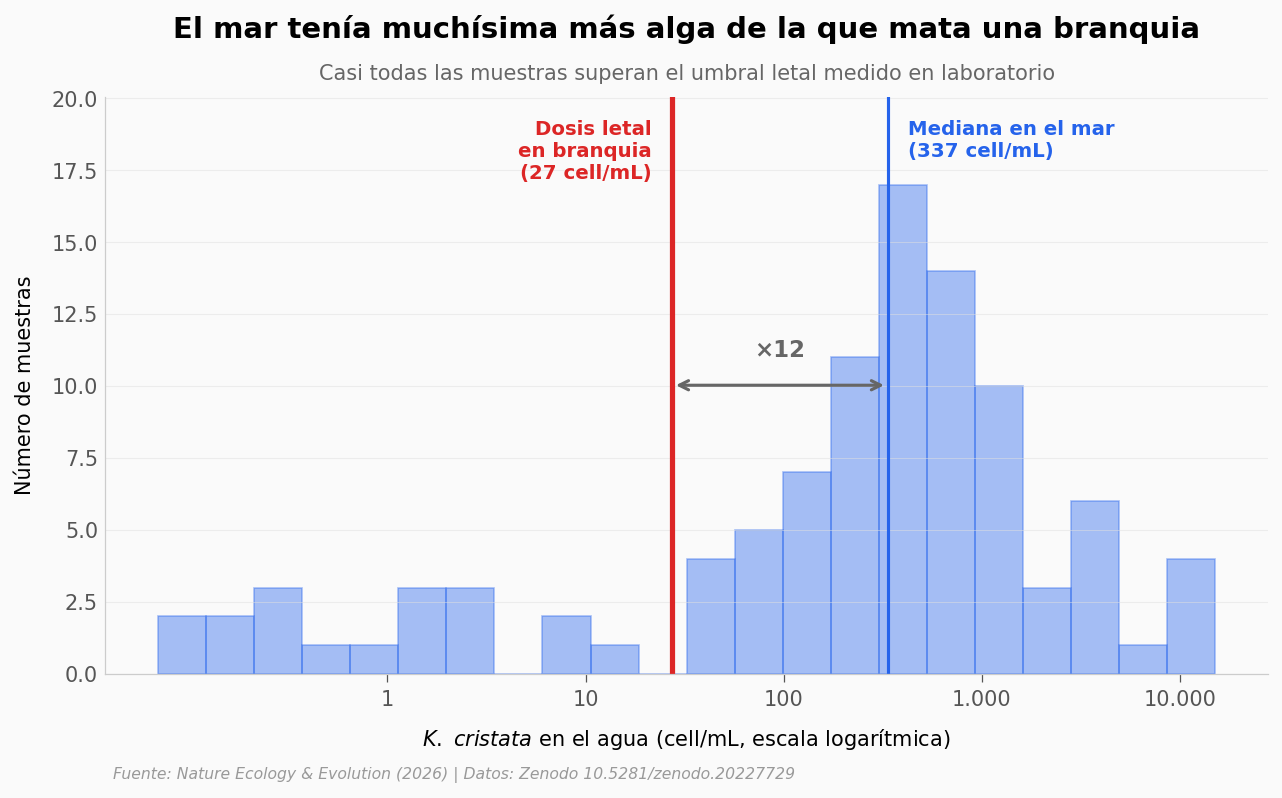

Mediana en el mar: 337 cell/mL  (12x el umbral letal)
Máximo en el mar: 15.015 cell/mL  (552x el umbral letal)
Muestras por encima del umbral letal: 82%


In [5]:
# ¿El mar superó la dosis letal de laboratorio?
# Convertimos la abundancia de campo (cells/L) a cells/mL para compararla con el EC50 de branquias
campo = abund.loc[abund[ESPECIE_FOCO] > 0, ESPECIE_FOCO] / 1000.0  # cells/mL
log_campo = np.log10(campo)
mediana = campo.median()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(log_campo, bins=22, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# umbral letal de branquias
x_ec50 = np.log10(GILL_EC50)
ax.axvline(x=x_ec50, color=COLOR_ALERTA, linewidth=2.5)
ax.text(x_ec50 - 0.10, y_max * 0.96, f'Dosis letal\nen branquia\n({GILL_EC50:.0f} cell/mL)',
        color=COLOR_ALERTA, fontsize=9.5, fontweight='bold', ha='right', va='top')
# mediana de campo
x_med = np.log10(mediana)
ax.axvline(x=x_med, color=COLOR_DATOS, linewidth=1.5)
ax.text(x_med + 0.10, y_max * 0.96, f'Mediana en el mar\n({mediana:,.0f} cell/mL)'.replace(',', '.'),
        color=COLOR_DATOS, fontsize=9.5, fontweight='bold', ha='left', va='top')
# flecha de la diferencia
ax.annotate('', xy=(x_med, y_max * 0.5), xytext=(x_ec50, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((x_ec50 + x_med) / 2, y_max * 0.55, f'×{mediana/GILL_EC50:.0f}',
        color='#666666', fontsize=11, fontweight='bold', ha='center')

# eje x en cell/mL reales, no en log
ticks = [1, 10, 100, 1000, 10000]
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([f'{t:,}'.replace(',', '.') for t in ticks])
ax.set_xlabel('$K.$ $cristata$ en el agua (cell/mL, escala logarítmica)', fontsize=10)
ax.set_ylabel('Número de muestras', fontsize=10)
ax.set_title('El mar tenía muchísima más alga de la que mata una branquia',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Casi todas las muestras superan el umbral letal medido en laboratorio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_umbral.png', dpi=200, bbox_inches='tight')
plt.show()

sobre_umbral = (campo > GILL_EC50).mean() * 100
print(f'Mediana en el mar: {mediana:,.0f} cell/mL  ({mediana/GILL_EC50:.0f}x el umbral letal)'.replace(',', '.'))
print(f'Máximo en el mar: {campo.max():,.0f} cell/mL  ({campo.max()/GILL_EC50:.0f}x el umbral letal)'.replace(',', '.'))
print(f'Muestras por encima del umbral letal: {sobre_umbral:.0f}%')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| *K. cristata* dominó la floración | ✅ | 88,6% del total de células de *Karenia*; la más abundante en 96 de 115 muestras; 11× sobre la segunda especie |
| El alga es tóxica para branquias | ✅ | Dosis-respuesta monotónica fuerte (Spearman ρ = −0,93; p < 0,001; n = 40); viabilidad cae de ~100% a ~2%; EC50 ≈ 27 cell/mL |
| El cultivo aislado reproduce la toxicidad de campo | ✅ | WL (campo) y KC (cultivo puro) matan igual a rotíferos y *Artemia* — cierra el vínculo causal alga→muerte |
| Rotíferos más sensibles que *Artemia* | ✅ | Rotíferos hasta 100% de mortalidad; *Artemia* hasta ~80%, con línea base más alta (18%) |
| El mar superó el umbral letal de laboratorio | ✅ | Mediana de campo ~337 cell/mL ≈ 12× el EC50 de branquia; picos de ~15.000 cell/mL, cientos de veces por encima |

> **Limitaciones:** el EC50 de ~27 cell/mL viene de células de branquia de trucha *in vitro* (2 h de exposición), no del pez entero ni de las especies que realmente murieron — es un indicador de potencia, no la dosis letal en la naturaleza. Las diluciones de invertebrados son ruidosas y pocas, así que reportamos tendencia (Spearman) y extremos, no una LC50 puntual. El mecanismo que concentró la floración en esa costa (hidrodinámica, ola de calor marina) **no** se prueba con estos datos; los autores lo plantean como hipótesis.

## Ahora tú

Los datos están completos y son tuyos. Tres preguntas para explorar:

1. **¿Cambia la historia si miras sitio por sitio?** El 88,6% es la suma de todo. Prueba agrupando `abund` por `location` y mirando dónde *K. cristata* fue más extrema. Pista: `abund.groupby('location')['K. cristata'].max()`.
2. **¿A qué concentración muere el 50% de los rotíferos?** Tenemos la curva; te falta interpolar. Pista: ordena `inv[inv.test=='Rotifers']` por `conc_cell_L` y busca dónde la mortalidad cruza 0,5.
3. **¿La floración creció con el tiempo?** Las muestras van de marzo a septiembre. Prueba graficar la abundancia de *K. cristata* contra `date` y mira si el pico llega en algún mes.

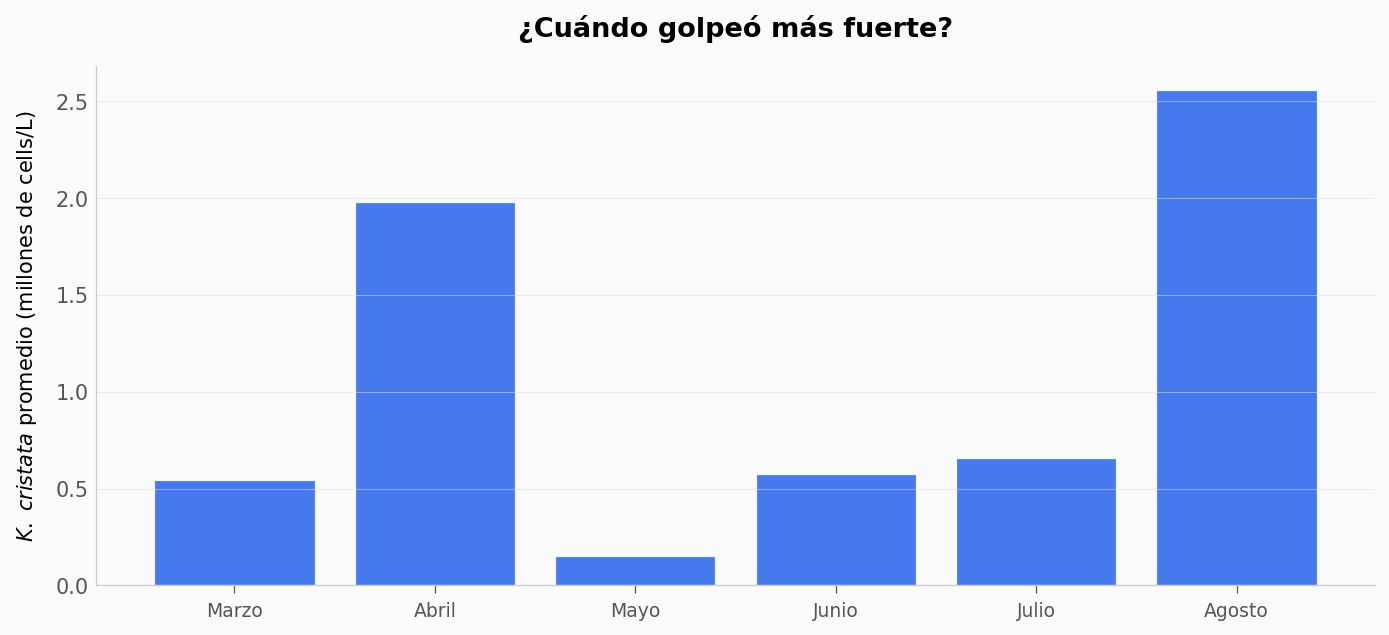

month
March         545286.0
May          1978042.0
June          151085.0
July          577786.0
August        658099.0
September    2556660.0
Name: K. cristata, dtype: float64


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿En qué mes fue peor la floración? Abundancia media de K. cristata por mes.
orden_meses = ['March', 'April', 'May', 'June', 'July', 'August', 'September']
por_mes = (abund.groupby('month')[ESPECIE_FOCO].mean()
           .reindex(orden_meses).dropna())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(range(len(por_mes)), por_mes.values / 1e6, color=COLOR_DATOS, alpha=0.85,
       edgecolor='white', linewidth=0.6)
ax.set_xticks(range(len(por_mes)))
ax.set_xticklabels(['Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre'][:len(por_mes)],
                   fontsize=9)
ax.set_ylabel('$K.$ $cristata$ promedio (millones de cells/L)', fontsize=10)
ax.set_title('¿Cuándo golpeó más fuerte?', fontsize=13, fontweight='bold', pad=14)
plt.savefig('figuras/experimenta_meses.png', dpi=200, bbox_inches='tight')
plt.show()
print(por_mes.round(0))

## Fuentes

**Paper**: [A catastrophic marine mortality event caused by a complex algal bloom including the brevetoxin producer Karenia cristata](https://doi.org/10.1038/s41559-026-03115-0)  
*Nature Ecology & Evolution, 2026-07-06*

**Dataset canónico**: [Data for: A catastrophic marine mortality event caused by a complex algal bloom including the novel brevetoxin producer Karenia cristata](https://doi.org/10.5281/zenodo.20227729)  
*Zenodo, 2026-05-16*

**Referencias citadas**: [Marine Heatwave Tracker (contexto oceanografico, citado no abierto por el notebook)](https://doi.org/10.5281/zenodo.3787872)

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*